In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# 1. 检测 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

# 显示 GPU 的名称（如果可用）
if torch.cuda.is_available():
    print(f"GPU 名称: {torch.cuda.get_device_name(0)}")

当前使用的设备: cuda
GPU 名称: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [3]:
# 2. 数据预处理 - 必须包含 Resize
transform = transforms.Compose([
    transforms.Resize(224), # AlexNet 必须的尺寸
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 下载 CIFAR-10 数据集
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

100%|██████████| 170M/170M [02:02<00:00, 1.39MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data


In [4]:
# 3. 定义 AlexNet
class AlexNet(nn.Module):
    def __init__(self, num_classes=10): # CIFAR-10 有 10 个类
        super(AlexNet, self).__init__() # 调用父类的构造函数, 以确保正确初始化
        self.features = nn.Sequential( # 定义卷积层部分
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential( # 定义全连接层部分
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [5]:
# 4. 初始化模型并搬运至 GPU
model = AlexNet(num_classes=10).to(device)

# 5. 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 6. 训练循环
print("开始训练...")
model.train()
for epoch in range(2): # 演示运行 2 个 epoch
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 关键步骤：将输入数据和标签也传送到 GPU
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print("训练完成！")

开始训练...
[Epoch 1, Batch 100] loss: 2.303
[Epoch 1, Batch 200] loss: 2.302
[Epoch 1, Batch 300] loss: 2.273
[Epoch 1, Batch 400] loss: 2.048
[Epoch 1, Batch 500] loss: 1.857
[Epoch 1, Batch 600] loss: 1.725
[Epoch 1, Batch 700] loss: 1.636
[Epoch 2, Batch 100] loss: 1.504
[Epoch 2, Batch 200] loss: 1.438
[Epoch 2, Batch 300] loss: 1.373
[Epoch 2, Batch 400] loss: 1.353
[Epoch 2, Batch 500] loss: 1.295
[Epoch 2, Batch 600] loss: 1.229
[Epoch 2, Batch 700] loss: 1.208
训练完成！


In [6]:
class FeatureHook:
    """用 forward hook 捕获中间层输出"""
    def __init__(self, module, name):
        self.name = name
        self.hook = module.register_forward_hook(self.hook_fn)
        self.output = None

    def hook_fn(self, module, input, output):
        # 只保存一份到 CPU，避免占用 GPU 显存
        self.output = output.detach().cpu()

    def close(self):
        self.hook.remove()


def visualize_feature_maps(model, x, layers_to_hook=None, max_channels=16, title_prefix=""):
    """
    model: 你的 AlexNet 实例
    x: 输入张量，形状 (1,3,H,W)
    layers_to_hook: 要 hook 的层索引列表（对应 model.features 的索引），None 表示自动挑 Conv/Pool
    max_channels: 每层最多画多少个通道
    """
    model.eval()

    # 自动选择：Conv2d 和 MaxPool2d（更有信息密度）
    if layers_to_hook is None:
        layers_to_hook = []
        for idx, m in enumerate(model.features):
            if isinstance(m, (nn.Conv2d, nn.MaxPool2d)):
                layers_to_hook.append(idx)

    hooks = []
    for idx in layers_to_hook:
        hooks.append(FeatureHook(model.features[idx], name=f"features[{idx}]={model.features[idx].__class__.__name__}"))

    with torch.no_grad():
        _ = model(x)  # 正向传播触发 hook

    for h in hooks:
        feat = h.output  # shape: (B, C, H, W)
        if feat is None:
            continue

        # 只看 batch 里的第一张
        fmap = feat[0]  # (C, H, W)
        c, hgt, wdt = fmap.shape

        # 选前 max_channels 个通道来画
        k = min(max_channels, c)
        cols = 4
        rows = (k + cols - 1) // cols

        plt.figure(figsize=(cols * 3, rows * 3))
        plt.suptitle(f"{title_prefix}{h.name}  output: ({c}, {hgt}, {wdt})", fontsize=12)

        for i in range(k):
            ax = plt.subplot(rows, cols, i + 1)
            img = fmap[i].numpy()

            # 为了更容易看：做一个 min-max 归一化到 [0,1]
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)

            ax.imshow(img, cmap="gray")
            ax.axis("off")
            ax.set_title(f"ch {i}", fontsize=9)

        plt.tight_layout()
        plt.show()

    for h in hooks:
        h.close()


In [8]:
# 下载 CIFAR-10 数据集 (Colab 环境下下载很快)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

Files already downloaded and verified


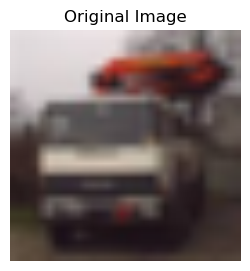

In [15]:
# ====== 训练完成后做一次可视化 ======
model.eval()

import random

# 从整个 testloader 里随机挑一个 batch
all_batches = list(testloader)
batch = random.choice(all_batches)

sample_inputs, sample_labels = batch
x_vis = sample_inputs[0:1].to(device)  # 仍取这个 batch 的第一张

# 原图显示保持不变
img = sample_inputs[0].permute(1, 2, 0).cpu().numpy()



# 反归一化（如果你训练时做了 Normalize）
mean = [0.5, 0.5, 0.5]
std  = [0.5, 0.5, 0.5]
img = img * std + mean
img = img.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

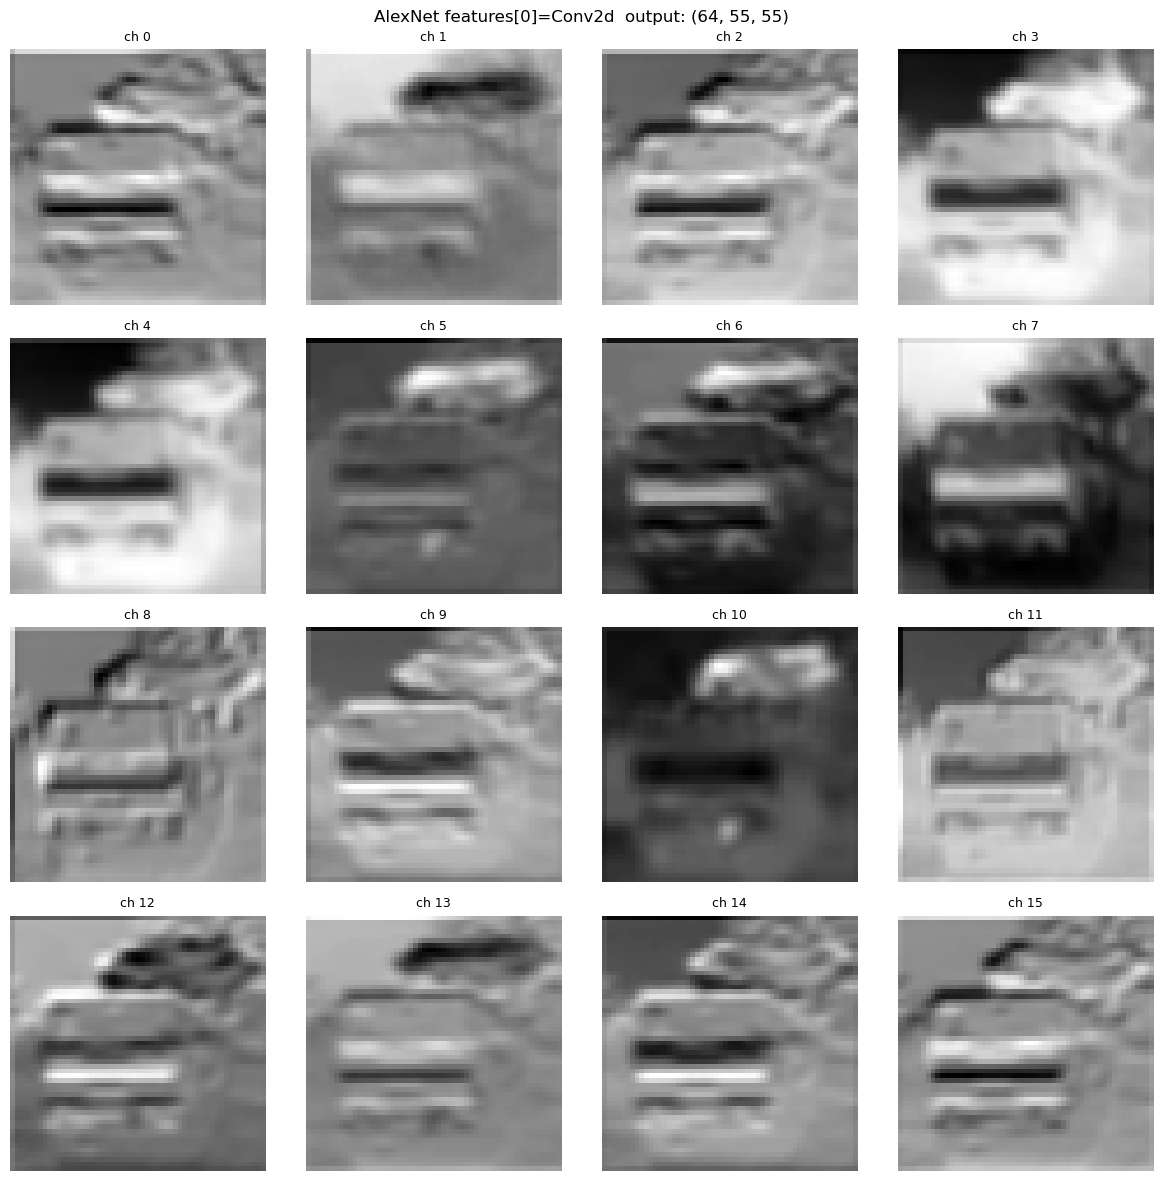

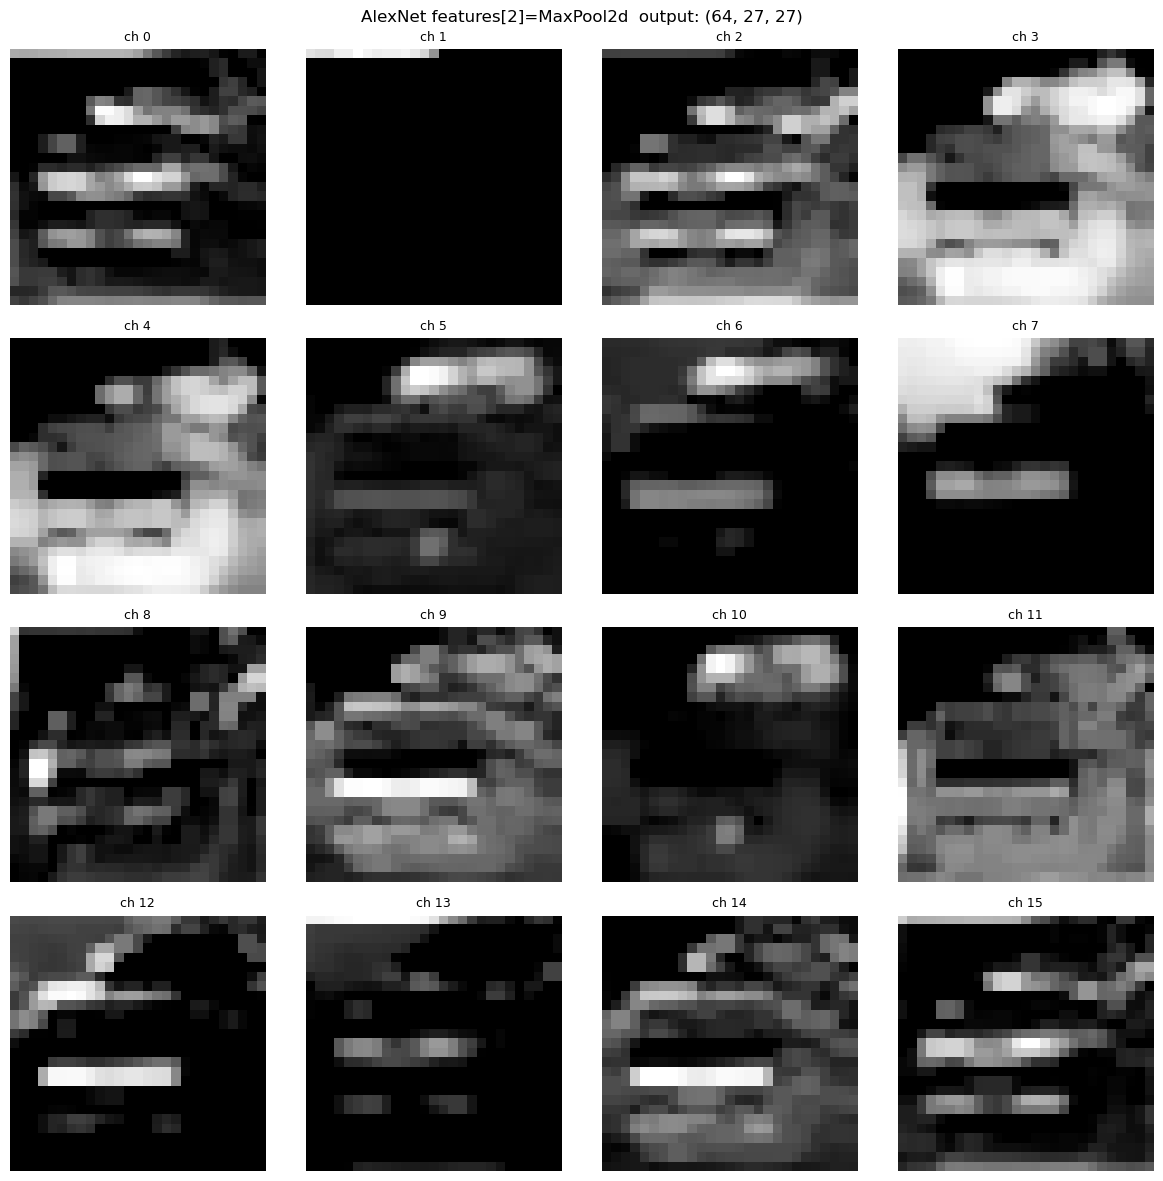

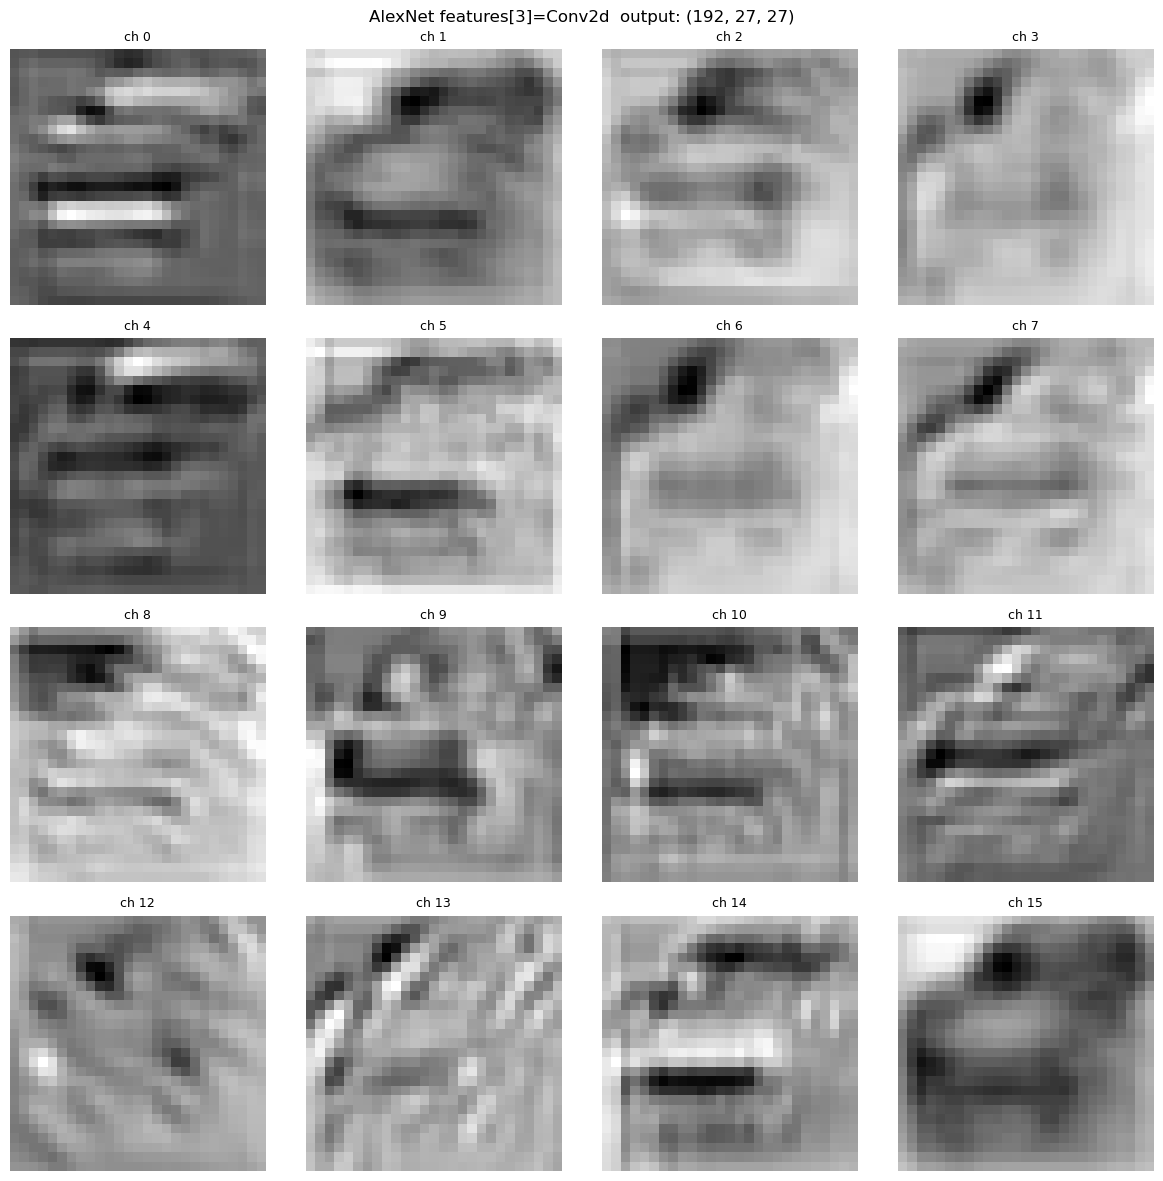

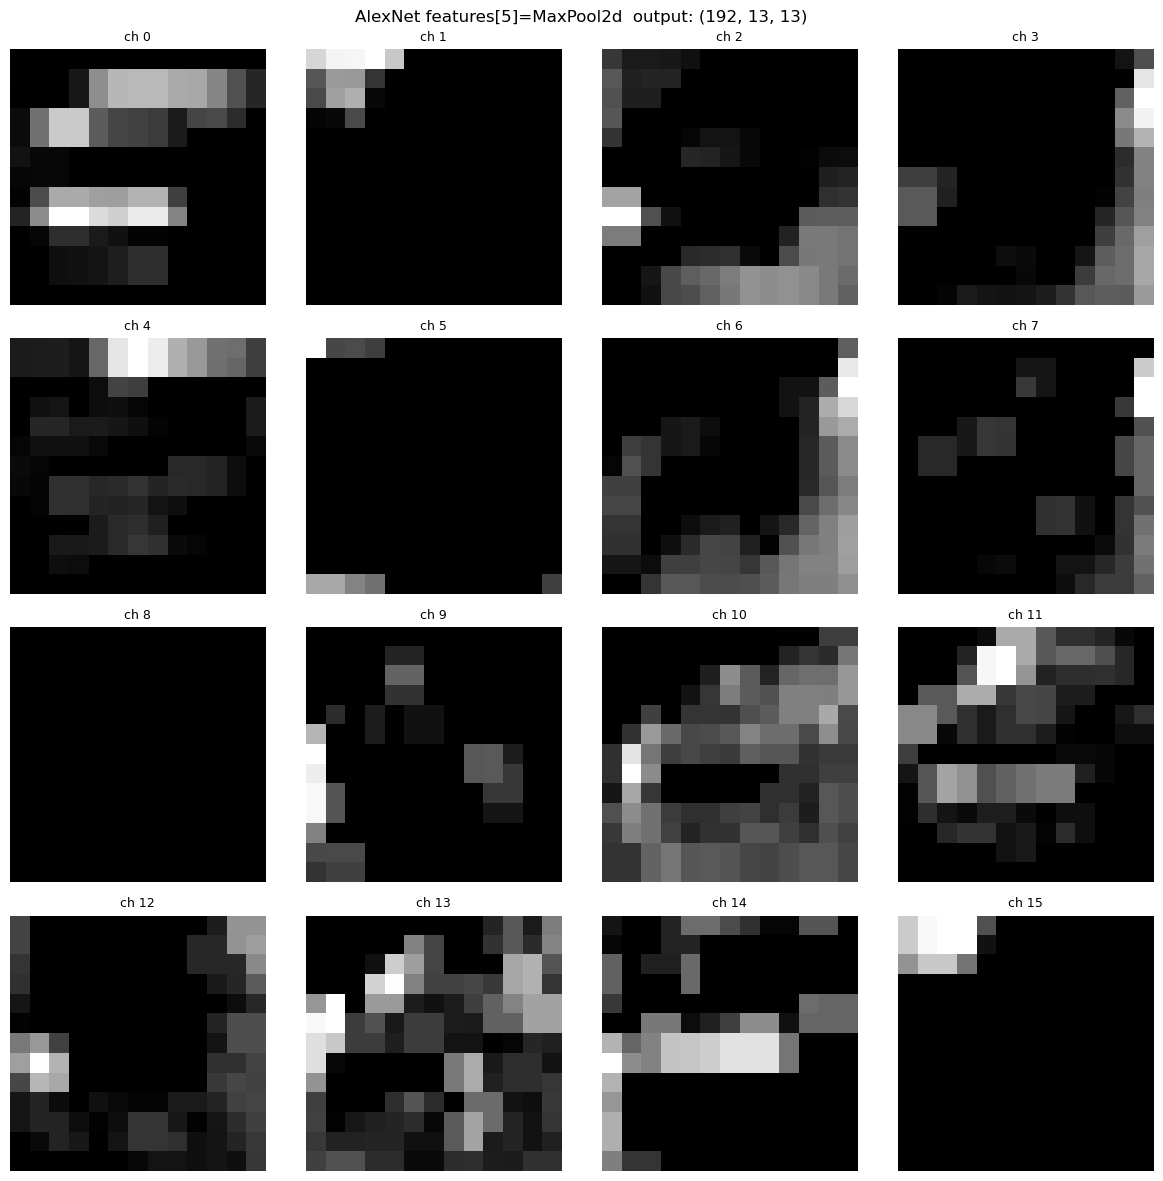

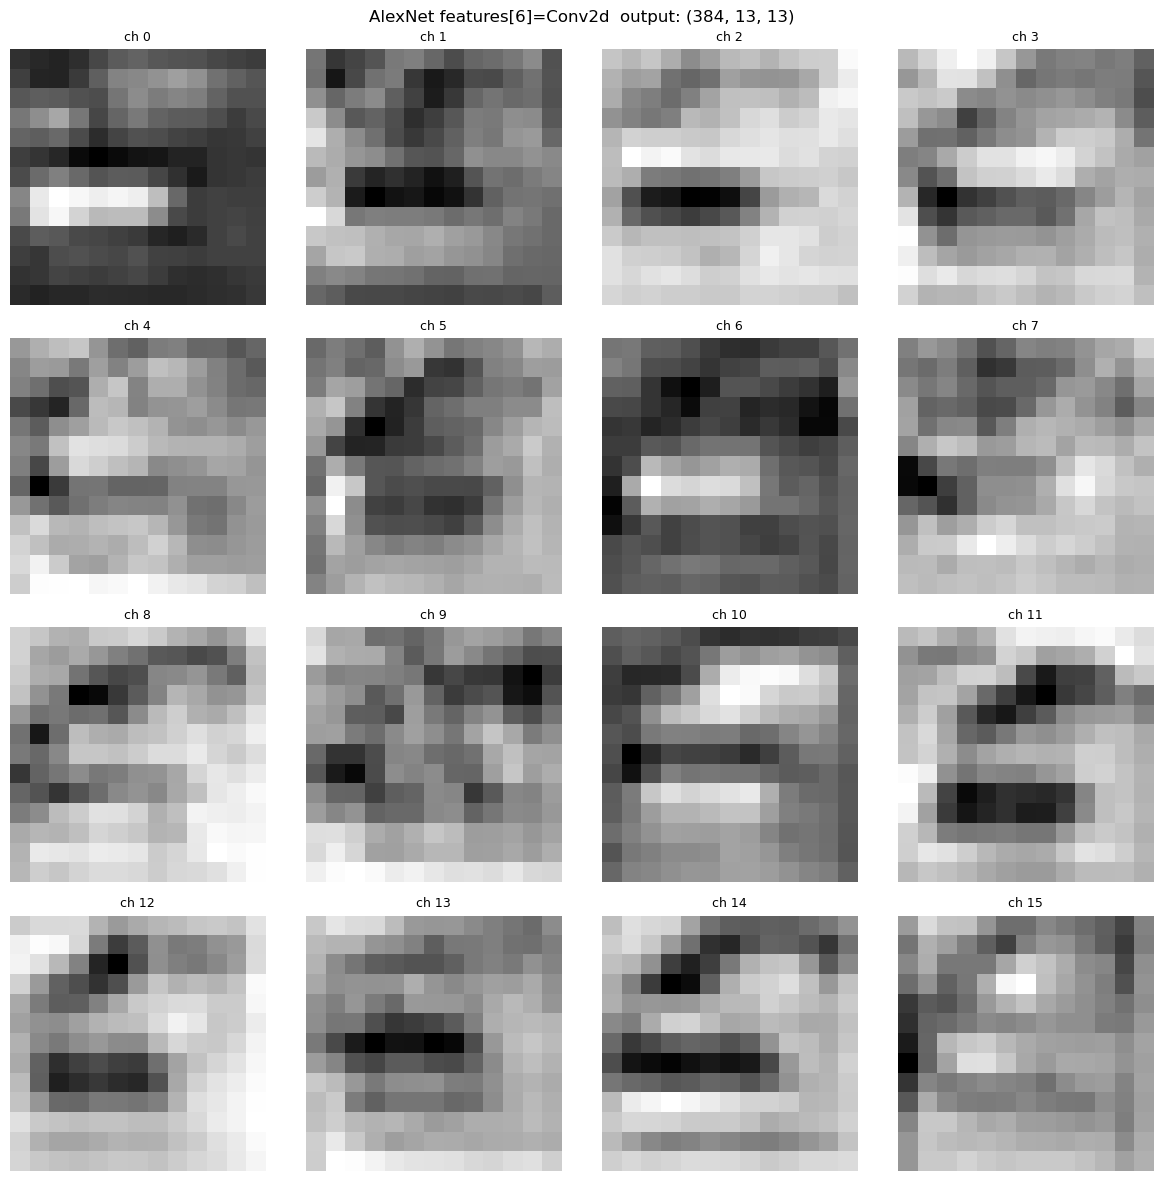

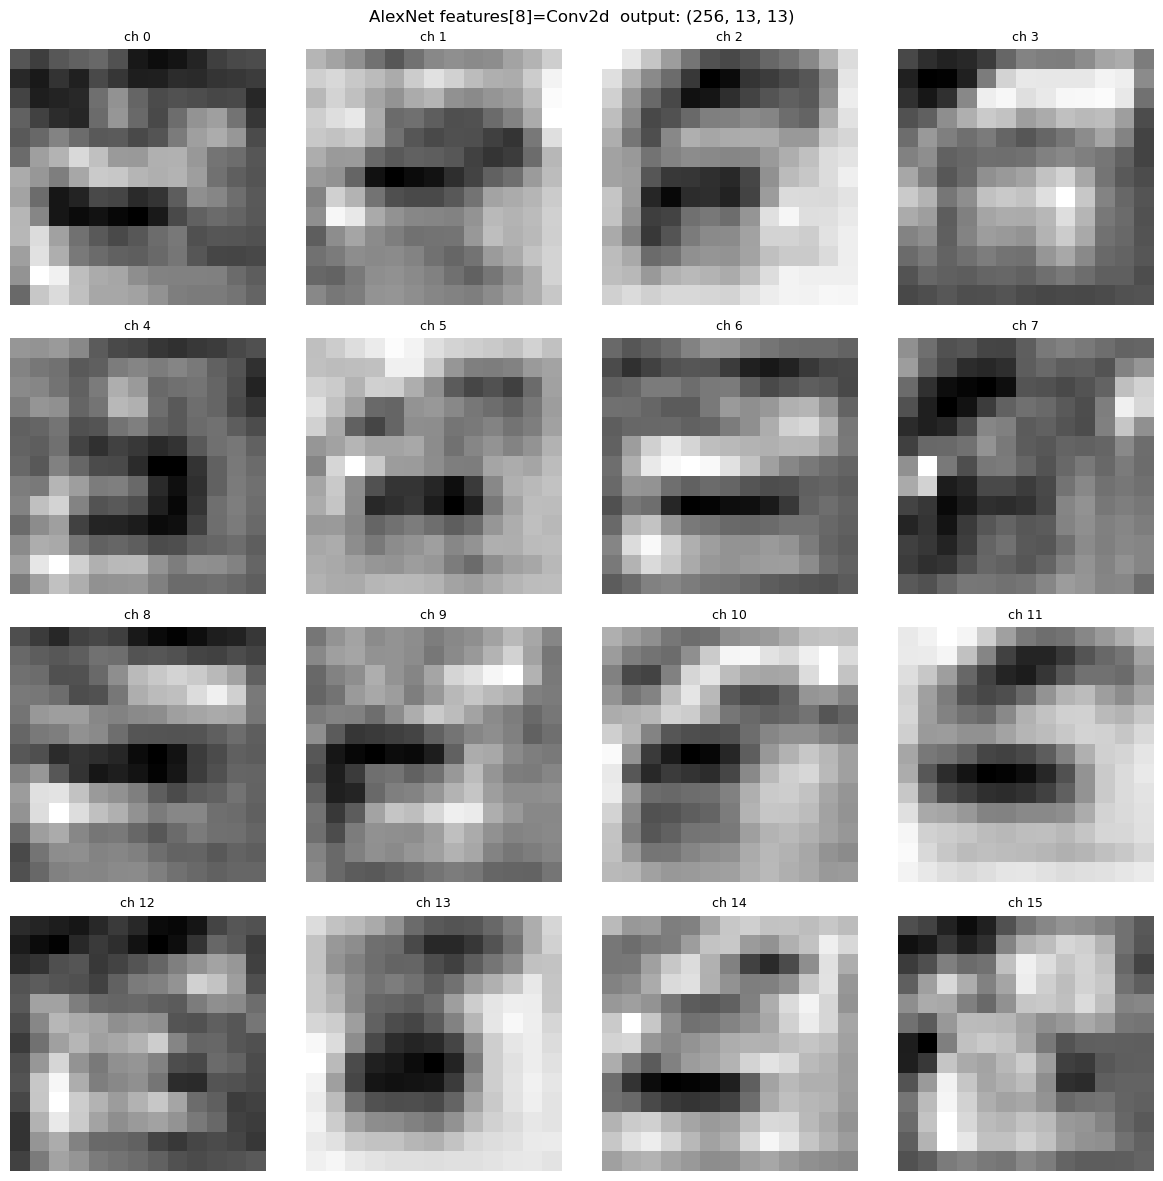

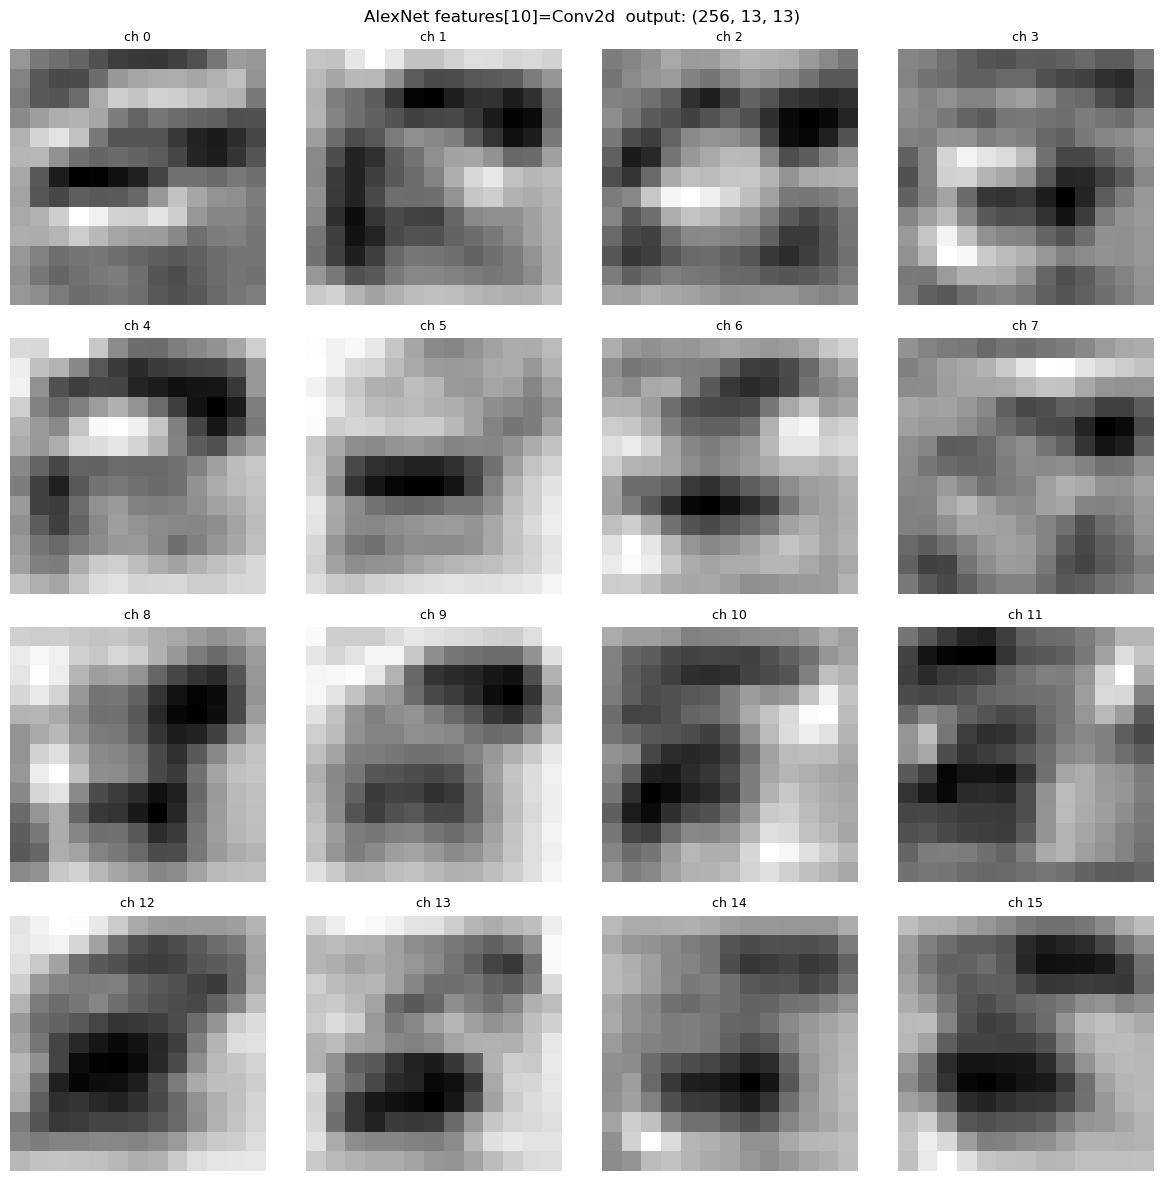

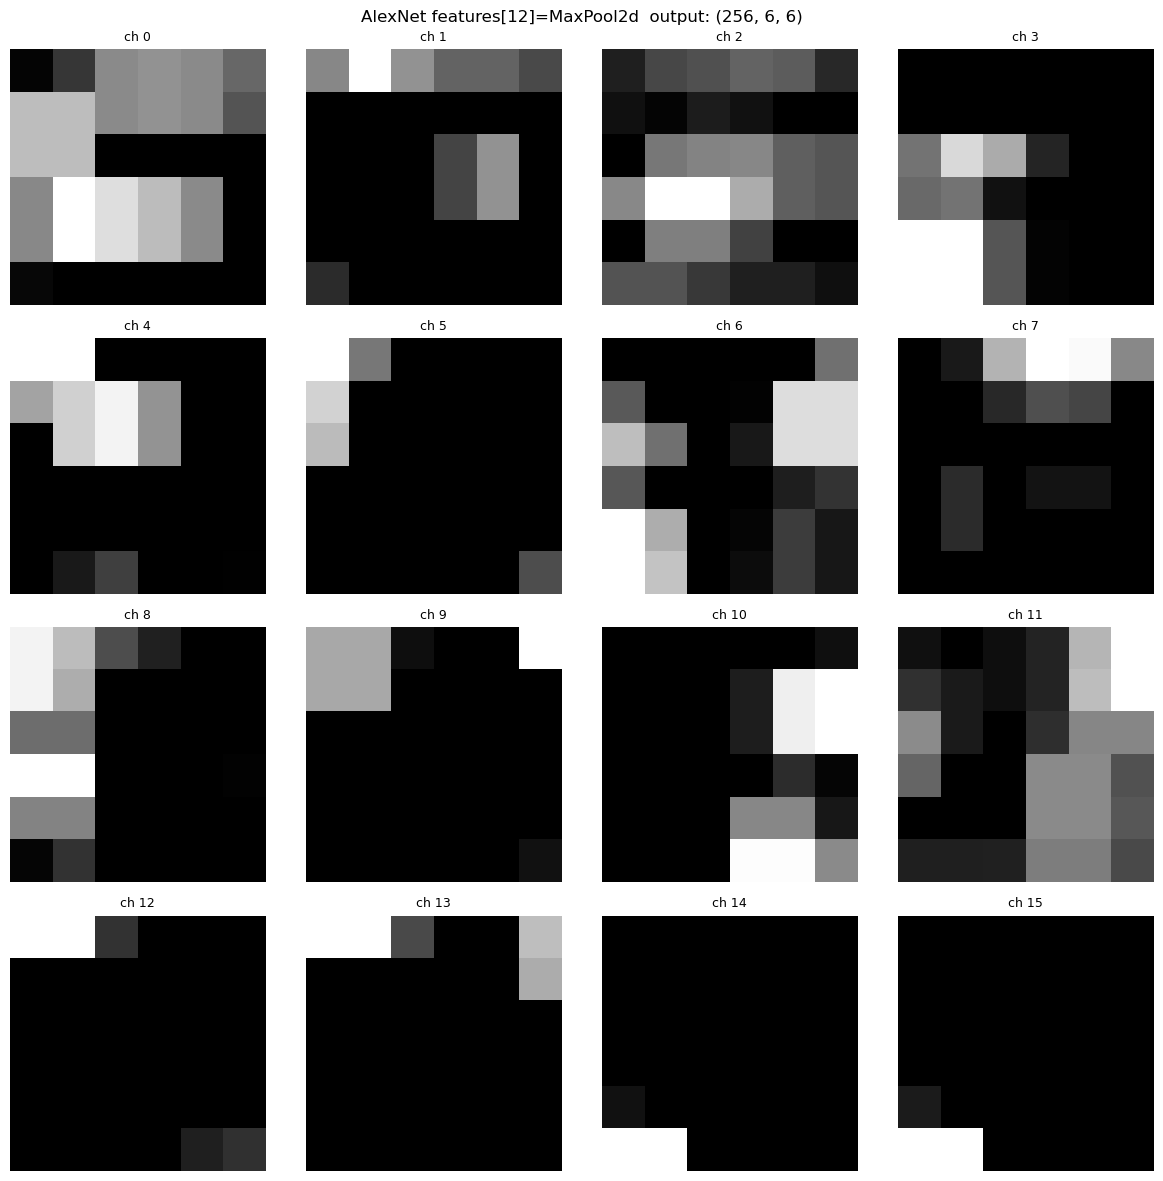

In [16]:
visualize_feature_maps(
    model,
    x_vis,
    layers_to_hook=None,     # None = 自动选择 Conv 和 Pool 层
    max_channels=16,
    title_prefix="AlexNet "
)
